In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import arviz as az
import scipy.stats as stats


# python font no dingbattes
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Helvetica Neue", "Arial", "DejaVu Sans", "Bitstream Vera Sans", "sans-serif"] 

In [3]:
sns.set_context("notebook", font_scale=1.3)

In [4]:
#Change the working directory
import os
os.chdir('/home/apoorva/Desktop/MZB-new-analysis')

In [5]:
Total_countsdf = pd.read_csv("data/New_data/new_data_MZB.csv") # counts for the host compartment MZ B cell population
print(Total_countsdf)
#Ignore the last observation
Total_countsdf1 = Total_countsdf[:-1]
# Ignore fraction of Ki67 donor and host < 0.7
Total_countsdf2 = Total_countsdf[Total_countsdf['frac_Ki67+_T2_donor'] >= 0.7]
Total_countsdf3 = Total_countsdf[Total_countsdf['frac_Ki67+_T2_host'] >= 0.7]

# Remove an obervation with days postBmt 117 and 82 with Nfd <0.25
Total_countsdf2 = Total_countsdf[Total_countsdf['Days postBMT'] != 117]
Total_countsdf2 = Total_countsdf[~((Total_countsdf['Days postBMT'] == 82) & (Total_countsdf['fd_T2'] < 0.25))]

                                    Unnamed: 0  Age at BMT  Age at S1K  \
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          74          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

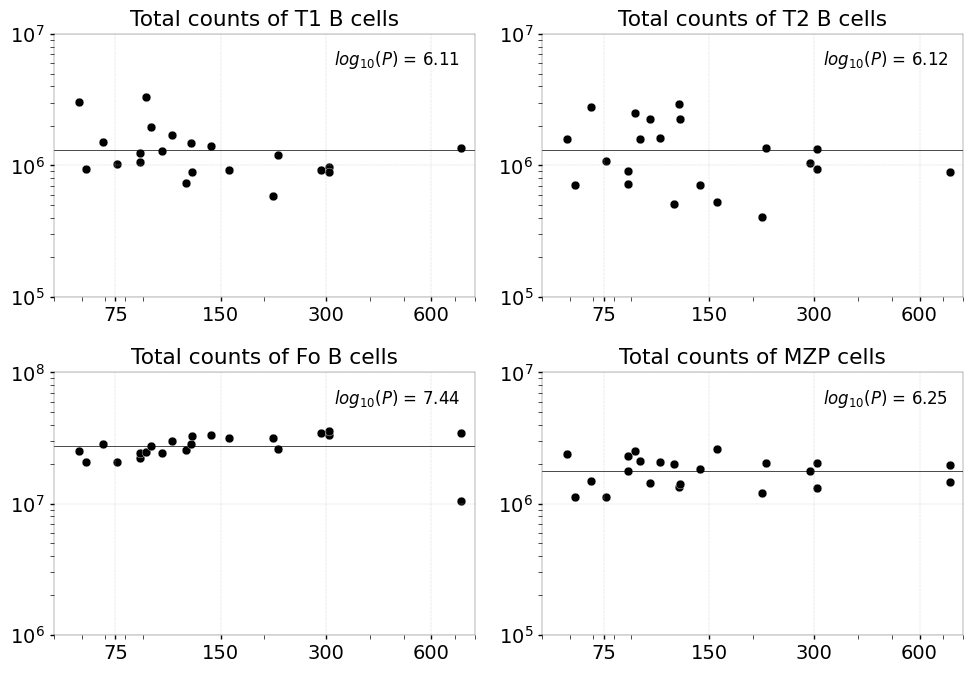

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]
# Plot total MZ cell counts for each precursor population
mean_T1 = Total_countsdf['total_T1_AA4.1+'].mean()
mean_T2= Total_countsdf['total_T2'].mean()
mean_FM= Total_countsdf['total_FM'].mean()
mean_T2MZP = Total_countsdf['total_T2_MZP'].mean()

# Invisible handle used for text-only legends (no marker/line shown)
text_only_handle = Line2D([], [], linestyle='none')

# Plot total T1 counts
sns.scatterplot(ax=ax1, data=Total_countsdf1, x='Age at S1K', y='total_T1_AA4.1+', s=40, linewidth=0.25,color='black')
ax1.axhline(y=mean_T1, linestyle='solid', linewidth=0.5,color='black')
ax1.set_yscale('log')  # sets the y-axis to a logarithmic scale
ax1.set_ylim(1e5, 1e7)
ax1.set_ylabel('')
ax1.set_xscale('log')
ax1.set_xlim(50, 800)
ax1.set_xticks([75, 150,  300,  600])
ax1.set_xticklabels([75, 150,  300,  600])
ax1.set_xlabel('')
ax1.set_title('Total counts of T1 B cells')
ax1.legend(handles=[text_only_handle], labels=[rf'$log_{{10}}(P)$ = {np.log10(mean_T1):.2f}'], loc='upper right', fontsize=12, frameon=False, handlelength=0, handletextpad=0)

# T2 Prcursor
sns.scatterplot(ax=ax2, data=Total_countsdf1, x='Age at S1K', y='total_T2', s=40, linewidth=0.25, color='black')
ax2.axhline(y=mean_T2, linestyle='solid', linewidth=0.5, color='black')
ax2.set_yscale('log')  # sets the y-axis to a logarithmic scale
ax2.set_ylim(1e5, 1e7)
ax2.set_ylabel('')
ax2.set_xscale('log')
ax2.set_xlim(50, 800)
ax2.set_xticks([75, 150,  300,  600])
ax2.set_xticklabels([75, 150,  300,  600])
ax2.set_xlabel('')
ax2.set_title('Total counts of T2 B cells')
ax2.legend(handles=[text_only_handle], labels=[rf'$log_{{10}}(P)$ = {np.log10(mean_T2):.2f}'], loc='upper right', fontsize=12, frameon=False, handlelength=0, handletextpad=0)

#Plot FM precursor
sns.scatterplot(ax=ax3, data=Total_countsdf, x='Age at S1K', y='total_FM', s=40, linewidth=0.25, color='black')
ax3.axhline(y=mean_FM, linestyle='solid', linewidth=0.5,color='black')
ax3.set_yscale('log')  # sets the y-axis to a logarithmic scale
ax3.set_ylim(1e6, 1e8)
ax3.set_ylabel('')
ax3.set_xscale('log')
ax3.set_xlim(50, 800)
ax3.set_xticks([75, 150,  300,  600])
ax3.set_xticklabels([75, 150,  300,  600])
ax3.set_xlabel('')
ax3.set_title('Total counts of Fo B cells')
ax3.legend(handles=[text_only_handle], labels=[rf'$log_{{10}}(P)$ = {np.log10(mean_FM):.2f}'], loc='upper right', fontsize=12, frameon=False, handlelength=0, handletextpad=0)

#Plot T2 MZP precursor
sns.scatterplot(ax=ax4, data=Total_countsdf, x='Age at S1K', y='total_T2_MZP', s=40, linewidth=0.25, color='black')
ax4.axhline(y=mean_T2MZP, linestyle='solid', linewidth=0.5, color='black')
ax4.set_yscale('log')  # sets the y-axis to a logarithmic scale
ax4.set_ylim(1e5, 1e7)
ax4.set_ylabel('')
ax4.set_xscale('log')
ax4.set_xlim(50, 800)
ax4.set_xticks([75, 150,  300,  600])
ax4.set_xticklabels([75, 150,  300,  600])
ax4.set_xlabel('')
ax4.set_title('Total counts of MZP cells')
ax4.legend(handles=[text_only_handle], labels=[rf'$log_{{10}}(P)$ = {np.log10(mean_T2MZP):.2f}'], loc='upper right', fontsize=12, frameon=False, handlelength=0, handletextpad=0)


# Axis border width and tick styling for all panels
for ax in [ax1, ax2, ax3, ax4]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.2)   # try 0.6 / 0.8 / 1.0

    # Tick mark width
    ax.tick_params(axis='both', which='both', width=0.8)
    ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
    ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
    ax.set_xlabel('')
    ax.tick_params(axis="both", labelsize=14)
    # tick mark size and thickness
    ax.tick_params(axis="both", which="major", length=3, width=1)
    ax.tick_params(axis="both", which="minor", length=3, width=0.5)

plt.tight_layout(rect=[0.0, 0.0, 1, 1])
# fig.text(0.06, 0.04, 'Host age (days)', ha='left', va='center')
# arrow = matplotlib.patches.FancyArrowPatch(
#     (0.25, 0.04),
#     (0.98, 0.04),
#     transform=fig.transFigure,
#     arrowstyle='->',
#     mutation_scale=12,
#     linewidth=0.5,
#     color='black',
# )
# fig.add_artist(arrow)
# fig.text(0.012, 0.5, 'Cell counts', ha='center', va='center', rotation=90)
# y_arrow = matplotlib.patches.FancyArrowPatch(
#     (0.04, 0.18),
#     (0.04, 0.92),
#     transform=fig.transFigure,
#     arrowstyle='->',
#     mutation_scale=12,
#     linewidth=0.5,
#     color='black',
# )
# fig.add_artist(y_arrow)
plt.savefig('Total_counts_precursordynamics.pdf', format='pdf', dpi=300)
plt.show()


In [7]:
def nfd_func(x, a, b, n):
    return   a*(1- np.exp(-b * (x-14)**n))

x_densefd = np.linspace(14, 690, 1000)
fd_t1 = nfd_func(x_densefd, 0.85, 0.1, 1)
fd_t2 = nfd_func(x_densefd, 0.83, 0.08, 1)
fd_fm = nfd_func(x_densefd, 0.8, 0.0005, 2)
fd_mzp = nfd_func(x_densefd, 0.8, 0.0003, 2)

mean_age_at_BMT = Total_countsdf['Age at BMT'].mean()
x_dense1 = x_densefd + 41

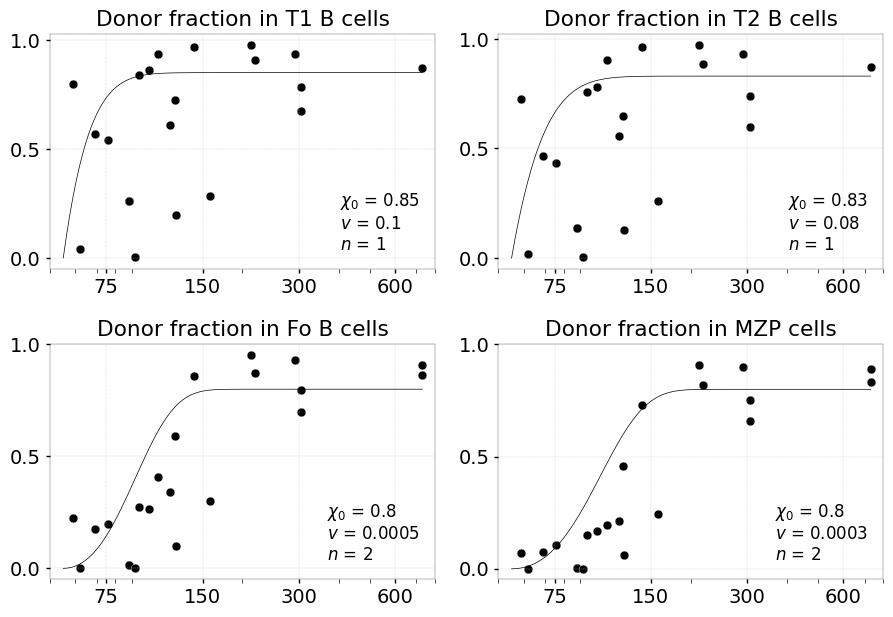

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]


# Plot total T1 counts
sns.scatterplot(ax=ax1, data=Total_countsdf1, x='Age at S1K', y='fd_T1_AA4.1+', s=40, linewidth=0.25,color='black')
ax1.plot(x_dense1, fd_t1, color='black', linestyle='-', linewidth=0.5)
ax1.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax1.set_ylabel('')
ax1.set_xscale('log')
ax1.set_xlim(50, 800)
ax1.set_xticks([75, 150,  300,  600])
ax1.set_xticklabels([75, 150,  300,  600])
ax1.set_xlabel('')
ax1.set_title('Donor fraction in T1 B cells')
ax1.legend(handles=[text_only_handle], labels=['$\chi_0$ = 0.85\n$v$ = $0.1$\n$n$ = 1'], frameon=False, fontsize=12, handlelength=0, handletextpad=0)


# T2 Prcursor
sns.scatterplot(ax=ax2, data=Total_countsdf1, x='Age at S1K', y='fd_T2', s=40, linewidth=0.25, color='black')
ax2.plot(x_dense1, fd_t2, color='black', linestyle='-', linewidth=0.5)
ax2.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax2.set_ylabel('')
ax2.set_xscale('log')
ax2.set_xlim(50, 800)
ax2.set_xticks([75, 150,  300,  600])
ax2.set_xticklabels([75, 150,  300,  600])
ax2.set_xlabel('')
ax2.set_title('Donor fraction in T2 B cells')
ax2.legend(handles=[text_only_handle], labels=['$\chi_0$ = 0.83\n$v$ = $0.08$\n$n$ = 1'], frameon=False, fontsize=12, handlelength=0, handletextpad=0)

#Plo FM precursor
sns.scatterplot(ax=ax3, data=Total_countsdf, x='Age at S1K', y='fd_FM', s=40, linewidth=0.25, color='black')
ax3.plot(x_dense1, fd_fm, color='black', linestyle='-', linewidth=0.5)
ax3.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax3.set_ylabel('')
ax3.set_xscale('log')
ax3.set_xlim(50, 800)
ax3.set_xticks([75, 150,  300,  600])
ax3.set_xticklabels([75, 150,  300,  600])
ax3.set_xlabel('')
ax3.set_title('Donor fraction in Fo B cells')
ax3.legend(handles=[text_only_handle], labels=['$\chi_0$ = 0.8\n$v$ = $0.0005$\n$n$ = 2'], frameon=False, fontsize=12, handlelength=0, handletextpad=0, loc='lower right')

#Plot T2 MZP precursor
sns.scatterplot(ax=ax4, data=Total_countsdf, x='Age at S1K', y='fd_T2_MZP', s=40, linewidth=0.25, color='black')
ax4.plot(x_dense1, fd_mzp, color='black', linestyle='-', linewidth=0.5)
ax4.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax4.set_ylabel('')
ax4.set_xscale('log')
ax4.set_xlim(50, 800)
ax4.set_xticks([75, 150,  300,  600])
ax4.set_xticklabels([75, 150,  300,  600])
ax4.set_xlabel('')
ax4.set_title('Donor fraction in MZP cells')
ax4.legend(handles=[text_only_handle], labels=['$\chi_0$ = 0.8\n$v$ = $0.0003$\n$n$ = 2'], frameon=False, fontsize=12, handlelength=0, handletextpad=0, loc='lower right')

# Axis border width and tick styling for all panels
for ax in [ax1, ax2, ax3, ax4]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.2)   # try 0.6 / 0.8 / 1.0

    # Tick mark width
    ax.tick_params(axis='both', which='both', width=0.8)
    ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
    ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
    ax.set_xlabel('')
    ax.tick_params(axis="both", labelsize=14)
    # tick mark size and thickness
    ax.tick_params(axis="both", which="major", length=3, width=1)
    ax.tick_params(axis="both", which="minor", length=3, width=0.5)
plt.tight_layout(rect=[0.08, 0.08, 1, 1])
# fig.text(0.06, 0.04, 'Host age (days)', ha='left', va='center')
# arrow = matplotlib.patches.FancyArrowPatch(
#     (0.25, 0.04),
#     (0.98, 0.04),
#     transform=fig.transFigure,
#     arrowstyle='->',
#     mutation_scale=12,
#     linewidth=0.5,
#     color='black',
# )
# fig.add_artist(arrow)

plt.savefig('Donor_fractions_precursordynamics.pdf', format='pdf', dpi=300)
plt.show()


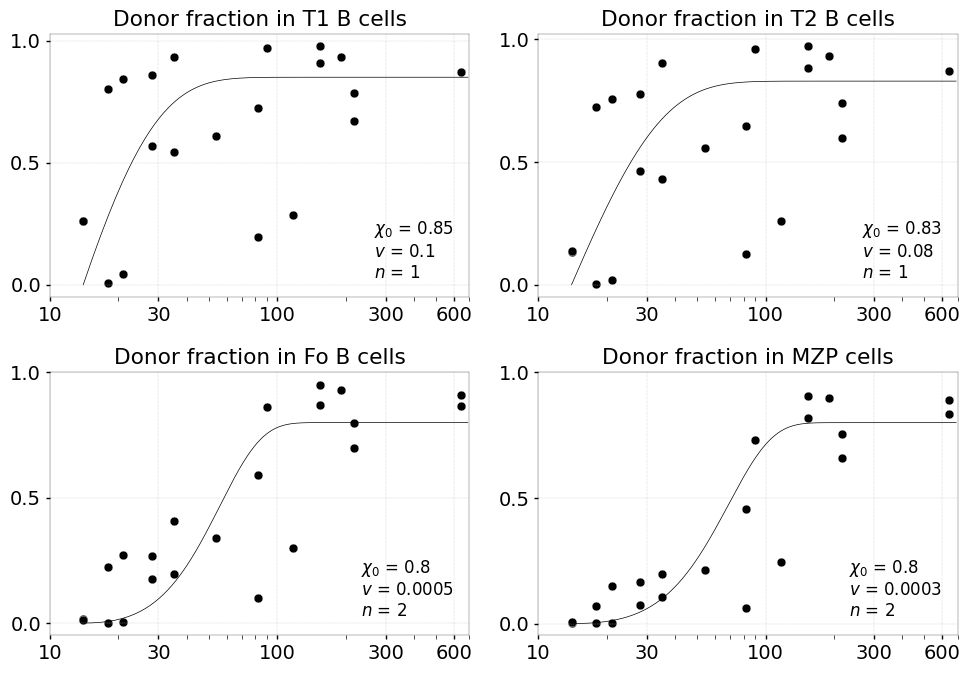

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

# text_only_handle = Line2D([], [], linestyle='none')
# Plot total T1 counts
sns.scatterplot(ax=ax1, data=Total_countsdf1, x='Days postBMT', y='fd_T1_AA4.1+', s=40, linewidth=0.25,color='black')
ax1.plot(x_densefd, fd_t1, color='black', linestyle='-', linewidth=0.5)
ax1.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax1.set_ylabel('')
ax1.set_xscale('log')
ax1.set_xlim(10, 700)
ax1.set_xticks([10, 30, 100,  300,  600])
ax1.set_xticklabels([10, 30, 100,  300,  600])
ax1.set_xlabel('')
ax1.set_title('Donor fraction in T1 B cells')
ax1.legend(handles=[text_only_handle], labels=['$\chi_0$ = 0.85\n$v$ = $0.1$\n$n$ = 1'], frameon=False, fontsize=12, handlelength=0, handletextpad=0)

# T2 Prcursor
sns.scatterplot(ax=ax2, data=Total_countsdf1, x='Days postBMT', y='fd_T2', s=40, linewidth=0.25, color='black')
ax2.plot(x_densefd, fd_t2, color='black', linestyle='-', linewidth=0.5)
ax2.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax2.set_ylabel('')
ax2.set_xscale('log')
ax2.set_xlim(10, 700)
ax2.set_xticks([10, 30, 100,  300,  600])
ax2.set_xticklabels([10, 30, 100,  300,  600])
ax2.set_xlabel('')
ax2.set_title('Donor fraction in T2 B cells')
ax2.legend(handles=[text_only_handle], labels=['$\chi_0$ = 0.83\n$v$ = $0.08$\n$n$ = 1'], frameon=False, fontsize=12, handlelength=0, handletextpad=0)

#Plot FM precursor
sns.scatterplot(ax=ax3, data=Total_countsdf, x='Days postBMT', y='fd_FM', s=40, linewidth=0.25, color='black')
ax3.plot(x_densefd, fd_fm, color='black', linestyle='-', linewidth=0.5)
ax3.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax3.set_ylabel('')
ax3.set_xscale('log')
ax3.set_xlim(10, 700)
ax3.set_xticks([10, 30, 100,  300,  600])
ax3.set_xticklabels([10, 30, 100,  300,  600])
ax3.set_xlabel('')
ax3.set_title('Donor fraction in Fo B cells')
ax3.legend(handles=[text_only_handle], labels=['$\chi_0$ = 0.8\n$v$ = $0.0005$\n$n$ = 2'], frameon=False, fontsize=12, handlelength=0, handletextpad=0, loc='lower right')

#Plot T2 MZP precursor
sns.scatterplot(ax=ax4, data=Total_countsdf, x='Days postBMT', y='fd_T2_MZP', s=40, linewidth=0.25, color='black')
ax4.plot(x_densefd, fd_mzp, color='black', linestyle='-', linewidth=0.5)
ax4.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax4.set_ylabel('')
ax4.set_xscale('log')
ax4.set_xlim(10, 700)
ax4.set_xticks([10, 30, 100,  300,  600])
ax4.set_xticklabels([10, 30, 100,  300,  600])
ax4.set_xlabel('')
ax4.set_title('Donor fraction in MZP cells')
ax4.legend(handles=[text_only_handle], labels=['$\chi_0$ = 0.8\n$v$ = $0.0003$\n$n$ = 2'], frameon=False, fontsize=12, handlelength=0, handletextpad=0, loc='lower right')


# Axis border width and tick styling for all panels
for ax in [ax1, ax2, ax3, ax4]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.2)   # try 0.6 / 0.8 / 1.0

    # Tick mark width
    ax.tick_params(axis='both', which='both', width=0.8)
    ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
    ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
    ax.set_xlabel('')
    ax.tick_params(axis="both", labelsize=14)
    # tick mark size and thickness
    ax.tick_params(axis="both", which="major", length=3, width=1)
    ax.tick_params(axis="both", which="minor", length=3, width=0.5)
plt.tight_layout(rect=[0.0, 0.0, 1, 1])
# fig.text(0.06, 0.04, 'Days post-BMT', ha='left', va='center')
# arrow = matplotlib.patches.FancyArrowPatch(
#     (0.25, 0.04),
#     (0.98, 0.04),
#     transform=fig.transFigure,
#     arrowstyle='->',
#     mutation_scale=12,
#     linewidth=0.5,
#     color='black',
# )
# fig.add_artist(arrow)

plt.savefig('Donor_fractions_dayspostbmt_precursordynamics.pdf', format='pdf', dpi=300)
plt.show()

In [10]:
def linear_model(x, a, b):
    return a*(x-40) + b

def gaussian_model(x, a, b, c):
    return  a*np.exp(-b*(x - 40)) + c

median_h_fm = Total_countsdf['frac_Ki67+_FM_host'].median()
median_h_mzp = Total_countsdf['frac_Ki67+_T2_MZP_host'].median()
x_dense = np.linspace(59, 750, 1000)
y_fit_donor_fm = gaussian_model(x_dense, 0.85, 0.025, 0.08)
y_fit_donor_mzp = gaussian_model(x_dense, 0.6, 0.03, 0.095)
y_fit_donor_t1 = linear_model(x_dense, -3.8e-5, 0.99)
y_fit_host_t1 = linear_model(x_dense, -1.7e-4, 0.98)
y_fit_donor_t2 = linear_model(x_dense, -1.9e-4, 0.97)
y_fit_host_t2 = linear_model(x_dense, -3.8e-5, 0.88)


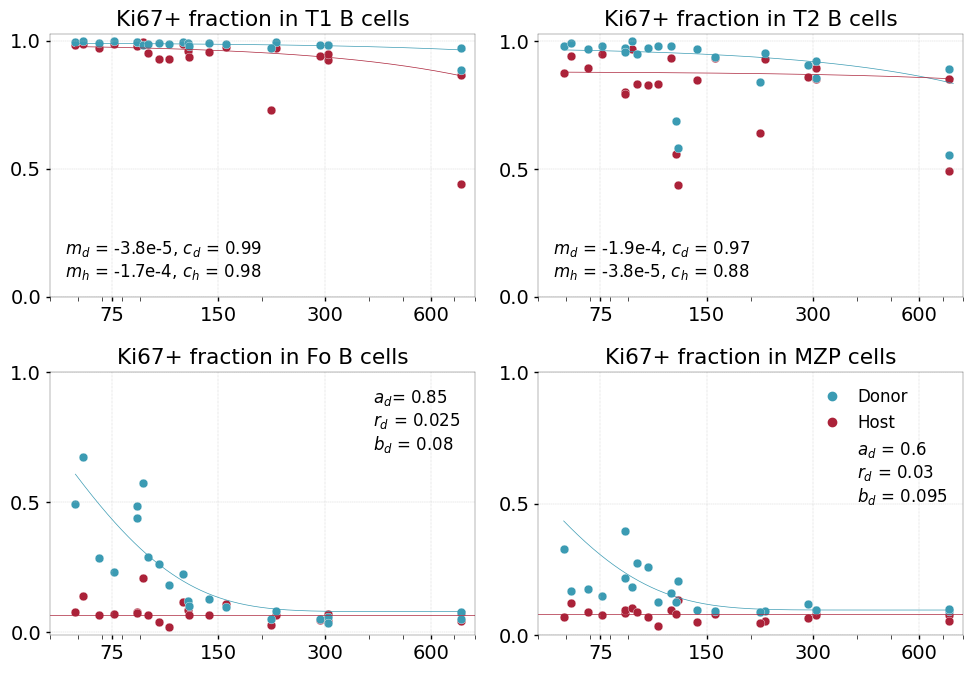

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

# Invisible handle used for text-only legends (no marker/line shown)
text_only_handle = Line2D([], [], linestyle='none')

# Plot fraction of Ki67+ T1 counts
sns.scatterplot(ax=ax1, data=Total_countsdf, x='Age at S1K', y='frac_Ki67+_T1_AA4.1+_host', s=40, linewidth=0.25, color='#ab2239', label= False)
sns.scatterplot(ax=ax1, data=Total_countsdf, x='Age at S1K', y= 'frac_Ki67+_T1_AA4.1+_donor', s=40, linewidth=0.25, color='#3b9bb3', label= False)
ax1.plot(x_dense, y_fit_donor_t1, color = '#3b9bb3', linewidth=0.5)
ax1.plot(x_dense, y_fit_host_t1, color = '#ab2239', linewidth=0.5)
ax1.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax1.set_ylabel('')
ax1.set_xscale('log')
ax1.set_xlim(50, 800)
ax1.set_xticks([75, 150,  300,  600])
ax1.set_xticklabels([75, 150,  300,  600])
ax1.set_xlabel('')
ax1.set_title('Ki67+ fraction in T1 B cells')
ax1.legend(handles=[text_only_handle], labels=['$m_d$ = -3.8e-5, $c_d$ = $0.99$\n$m_h$ = -1.7e-4, $c_h$ = $0.98$'], frameon=False, fontsize=12, handlelength=0, handletextpad=0)

# T2 Prcursor
sns.scatterplot(ax=ax2, data=Total_countsdf, x='Age at S1K', y='frac_Ki67+_T2_host',  s=40, linewidth=0.25, color='#ab2239', label= False)
sns.scatterplot(ax=ax2, data=Total_countsdf, x='Age at S1K', y= 'frac_Ki67+_T2_donor',  s=40,  linewidth=0.25,color='#3b9bb3', label= False)
ax2.plot(x_dense, y_fit_donor_t2, color = '#3b9bb3', linewidth=0.5)
ax2.plot(x_dense, y_fit_host_t2, color = '#ab2239', linewidth=0.5)
ax2.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax2.set_ylabel('')
ax2.set_xscale('log')
ax2.set_xlim(50, 800)
ax2.set_xticks([75, 150,  300,  600])
ax2.set_xticklabels([75, 150,  300,  600])
ax2.set_xlabel('')
ax2.set_title('Ki67+ fraction in T2 B cells')
ax2.legend(handles=[text_only_handle], labels=['$m_d$ = -1.9e-4, $c_d$ = $0.97$\n$m_h$ = -3.8e-5, $c_h$ = $0.88$'], frameon=False, fontsize=12, handlelength=0, handletextpad=0)

#Plot FM precursor
sns.scatterplot(ax=ax3, data=Total_countsdf, x='Age at S1K', y='frac_Ki67+_FM_host', s=40, linewidth=0.25,color='#ab2239')
sns.scatterplot(ax=ax3, data=Total_countsdf, x='Age at S1K', y= 'frac_Ki67+_FM_donor', s=40,  linewidth=0.25,color='#3b9bb3')
ax3.axhline(y=median_h_fm, linestyle='solid', color= '#ab2239', linewidth=0.5)
ax3.plot(x_dense, y_fit_donor_fm, color = '#3b9bb3', linewidth=0.5)
ax3.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax3.set_ylabel('')
ax3.set_xscale('log')
ax3.set_xlim(50, 800)
ax3.set_xticks([75, 150,  300,  600])
ax3.set_xticklabels([75, 150,  300,  600])
ax3.set_xlabel('')
ax3.set_title('Ki67+ fraction in Fo B cells')
ax3.legend(handles=[text_only_handle], labels=['$a_d$= $0.85$\n$r_d$ = $0.025$\n$b_d$ = $0.08$'], loc='upper right', fontsize=12, frameon=False, handlelength=0, handletextpad=0)

#Plot T2 MZP precursor
sns.scatterplot(ax=ax4, data=Total_countsdf, x='Age at S1K', y='frac_Ki67+_T2_MZP_host', s=40,linewidth=0.25, color='#ab2239')
sns.scatterplot(ax=ax4, data=Total_countsdf, x='Age at S1K', y= 'frac_Ki67+_T2_MZP_donor', s=40,  linewidth=0.25,color='#3b9bb3')
ax4.axhline(y=median_h_mzp, linestyle='solid', color= '#ab2239', linewidth=0.5)
ax4.plot(x_dense, y_fit_donor_mzp, color = '#3b9bb3', linewidth=0.5)
ax4.set_yticks(np.arange(0, 1.25, 0.25)[[0, 2, 4]])
ax4.set_ylabel('')
ax4.set_xscale('log')
ax4.set_xlim(50, 800)
ax4.set_xticks([75, 150,  300,  600])
ax4.set_xticklabels([75, 150,  300,  600])
ax4.set_xlabel('')
ax4.set_title('Ki67+ fraction in MZP cells')
donor_handle = Line2D([], [], color='#3b9bb3', marker='o', linestyle='none', markersize=6, label='Donor')
host_handle  = Line2D([], [], color='#ab2239', marker='o', linestyle='none', markersize=6, label='Host')
text_handle  = Line2D([], [], linestyle='none', label='$a_d$ = $0.6$\n$r_d$ = $0.03$\n$b_d$ = $0.095$')

ax4.legend(
    handles=[donor_handle, host_handle, text_handle],
    frameon=False,
    handlelength=1.8,
    handletextpad=0.6,fontsize=12, title_fontsize=12
)


# Axis border width and tick styling for all panels
for ax in [ax1, ax2, ax3, ax4]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.2)   # try 0.6 / 0.8 / 1.0

    # Tick mark width
    ax.tick_params(axis='both', which='both', width=0.8)
    ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
    ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
    ax.set_xlabel('')
    ax.tick_params(axis="both", labelsize=14)
    # tick mark size and thickness
    ax.tick_params(axis="both", which="major", length=3, width=1)
    ax.tick_params(axis="both", which="minor", length=3, width=0.5)

plt.tight_layout()
plt.savefig('Ki67_fractions_precursordynamics.pdf', format='pdf', dpi=300)
plt.show()